<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebooks/Section01_Supervised_Learning/Chapter01_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CLASSIFICATION**

After learning how to **predict continuous numbers** with regression, we now step into the world of **classification**, where our goal is different — **predicting categories**.

In **classification problems**, our model doesn’t output a continuous number like a price or weight.
Instead, it **assigns input data to discrete classes** — like this email is spam or not spam, this image is of a cat or a dog, this application is approved or rejected, this patient has cancer or not cancer, ...

The output is a **label**, a **class**, or a **category** — not a free-flowing number on an infinite scale.

## **Regression vs Classification**

Let’s see some clear examples to separate these two ideas:

|**Input**                               |**Regression**                       |  **Classification**                                            |
| ------------------------------------------- | --------------------------------------- | --------------------------------------------------------------- |
| Features of a house (size, rooms, location) | Predict the house **price**| Predict if it’s a **good investment** (*buy* / *don’t buy*)     |
| Customer data (income, age, spending)       | Predict **annual spending amount**      | Predict if they’ll **default** on a loan (*yes* / *no*)         |
| Email content (words, length)               | Predict **reading time** in minutes     | Predict if it’s **spam** (*spam* / *not spam*)                  |
| Medical data (age, weight, test results)    | Predict **blood sugar level**           | Predict if a patient has **diabetes** (*positive* / *negative*) |
| Weather data (temperature, humidity)        | Predict **tomorrow’s temperature**      | Predict if it’ll **rain** tomorrow (*rain* / *no rain*)         |

In **classification**, we learn **boundaries** that separate different categories. The goal is to find the best line, curve, or hyperplane that cuts the space and **splits data points** into the right class buckets.  

In **regression**, we tried to find a **line, curve, or hyperplane that captures the overall behavior of the data**. Instead of splitting points into categories, regression focused on **predicting continuous values** by following the underlying trend.

In [42]:
import numpy as np
import matplotlib.pyplot as plt

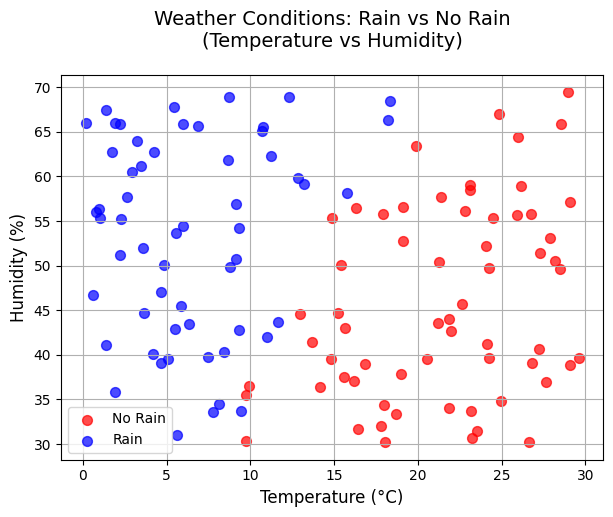

In [74]:
# Configuration parameters
N_SAMPLES = 120
NOISE_LEVEL = 5

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic weather data
temperature = np.random.random(N_SAMPLES) * 30  # Temperature range: 0-30°C
humidity = np.random.random(N_SAMPLES) * 40 + 30  # Humidity range: 30-70%

# Determine rain conditions based on temperature-humidity relationship
# Rain occurs when humidity > 3.5 * temperature + random noise
rain_threshold = 3.5 * temperature + np.random.normal(0, NOISE_LEVEL, N_SAMPLES)
rain = np.where(humidity > rain_threshold, 1, -1)  # 1 for rain, -1 for no rain

# Visualization settings
colors = ['red', 'blue']
labels = ['No Rain', 'Rain']
rain_values = [-1, 1]  # Corresponding to no rain and rain

# Create the scatter plot
plt.figure(figsize=(7, 5))
for color, label, rain_val in zip(colors, labels, rain_values):
    # Filter data points for current rain condition
    mask = (rain == rain_val)
    plt.scatter(
        temperature[mask],
        humidity[mask],
        c=color,
        label=label,
        alpha=0.7,
        s=50
    )

# Customize the plot
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)
plt.title('Weather Conditions: Rain vs No Rain\n(Temperature vs Humidity)', fontsize=14, pad=20)
plt.grid(True)
plt.legend()
plt.show()

## **Perceptron**

The **Perceptron** is one of the simplest yet most powerful ideas that kickstarted the entire field of **Neural Networks**. Inspired by the structure of a single **neuron** in the human brain, a perceptron takes multiple **inputs** (just like dendrites receiving signals) and combines them into a single **weighted sum**:

$$
Z = \mathbf{w} \cdot \mathbf{x} + \mathbf{b}
$$

Here,  
- **$\mathbf{x}$** is your input vector (features),  
- **$\mathbf{w}$** is the vector of **weights** (how much importance each input has),  
- and **$\mathbf{b}$** is the **bias** term — like a base level of stimulation for the neuron.

When this total input $Z$ reaches a certain **threshold**, the perceptron “fires” — producing an **output**. We then feed it into a function called the activation function $f(Z)$:  
- If $f(Z) = +1$ then “yes, activate!”  
- If $f(Z) = -1$ then “no, stay silent.”

---

### **Why the Perceptron Works**

Think of a human baby: its brain’s neurons start with no clear sense of the world — every input is treated equally at first. This is like initializing all weights of the `Perceptron` to zero or random small values. Over time, experiences **adjust** these connection strengths — so useful patterns (like recognizing a parent’s face) get stronger, while irrelevant ones fade away.  
The perceptron follows the same logic: by **updating** its weights, it learns which features matter for making a correct decision and how much they matter.

The key goal is to find weights that **correctly separate** your data into two groups (classes). The perceptron tweaks its weights to **reduce misclassified points**, just like neurons fine-tune connections to react to important signals.

---

### **One Is Not Enough**

A single perceptron can only separate your data with a **straight line** (or hyperplane in higher dimensions). But when you stack multiple perceptrons together — like layers of neurons in a brain — you get the power to learn complex, non-linear patterns.  
This is exactly how **deep learning** works: more neurons, more layers, more power (more on it in `Section04`.)


###**Structure of Perceptron**

The **Perceptron** is one of the earliest and simplest ideas for solving classification problems — and its inspiration comes directly from how neurons work in our brains.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S04_C00/neuron.png" width="700">
</div>

A biological neuron receives signals through its *dendrites*, sums them up, and if the total signal is strong enough, it *fires* an output signal through its *axon*.
Mathematically, our perceptron does exactly the same:

* It multiplies each input feature by a weight, sums them up, and adds a bias.
* This total input is just a single number, often called **Z**.
* If Z is greater than or equal to zero, the perceptron *fires* (outputs +1); if below zero, it stays silent (outputs -1).

When a perceptron is initialized, its weights start at zero — like a newborn brain with no knowledge or pattern recognition yet.
By seeing examples again and again, the perceptron adjusts its weights little by little so that the output matches the true labels.
A **learning rate** will control how big each weight adjustment is, and the **epochs** decide how many times the perceptron should pass through all the training examples.

---

### **Why an Activation Function?**

You might wonder: *“Why not just use the raw number Z (output of perceptron) to make decisions?”*
In regression, the output can be any continuous value. But in classification, we only care about which *side* of the decision boundary each point falls on.
So instead of working with all possible Z values, the perceptron uses a simple **sign activation function**:

$$
\text{sgn}(Z) =
\begin{cases}
+1 & \text{if } Z \geq 0 \\\\
-1 & \text{otherwise}
\end{cases}
$$

This way, the output is always discrete — either the point belongs to one class or the other.

---

### **How Learning Happens**

Whenever the perceptron makes a mistake (predicts +1 when it should be -1, or vice versa), it updates its weights to *push* the decision boundary in the right direction.
This update rule is simple:

$$
w = w + \eta \cdot (y - \hat{y}) \cdot x
$$

where:

* $w$ are the weights,
* $\eta$ is the learning rate,
* $y$ is the true label,
* $\hat{y}$ is the predicted label,
* $x$ is the input vector.

This continues for each training sample in each epoch.

But don't forget that the perceptron can only find **linear boundaries** — a straight line (or a hyperplane in higher dimensions) that separates the classes.
If the data is not linearly separable (due to noise or true overlap), the perceptron won’t reach perfect accuracy — but it still does its best to find the line that makes the fewest mistakes.

Learned weights (b, x1, x2): [ 0.002      -1.07323738  0.3034351 ]
Final misclassified samples: 3.0



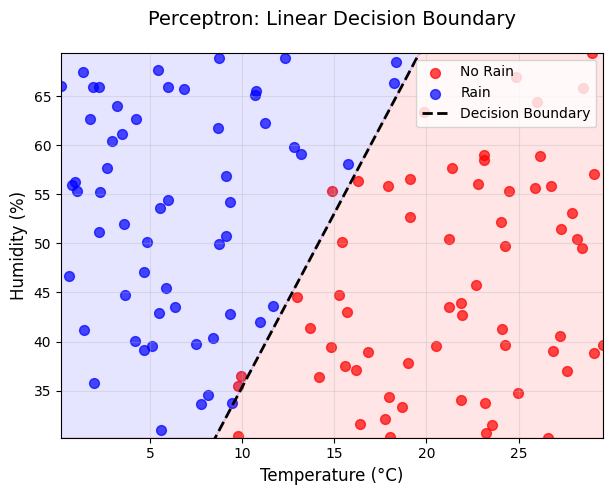

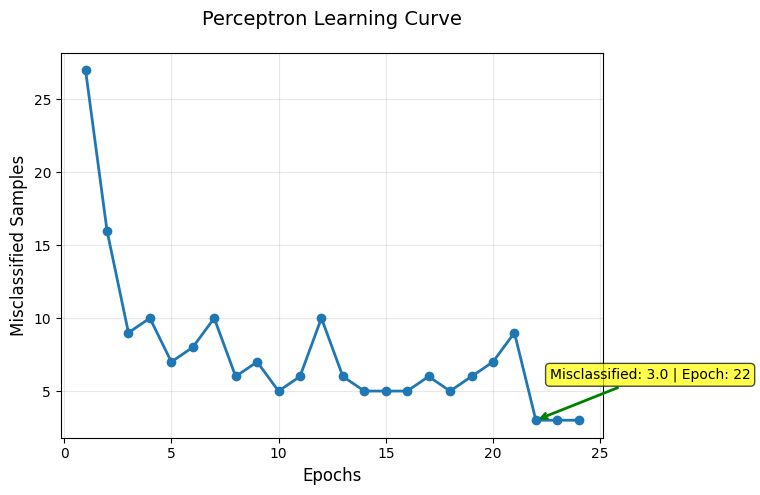

In [76]:
# Set random seed for reproducibility
np.random.seed(42)

class Perceptron:
    """
    A simple Perceptron classifier implementation for binary classification.
    """
    def __init__(self, learning_rate=0.01, epochs=1000):
        """
        Initialize the Perceptron.

        Args:
            learning_rate (float): Step size for weight updates
            epochs (int): Maximum number of training iterations
        """
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.misclassified_history = []

    def fit(self, X, y):
        """
        Train the perceptron on the given dataset.

        Args:
            X (array): Feature matrix with bias term (n_samples, n_features)
            y (array): Target labels (-1 or 1)
        """
        n_samples, n_features = X.shape

        # Initialize weights to zero
        self.weights = np.zeros(n_features)
        self.misclassified_history = []

        # Training loop
        for epoch in range(self.epochs):
            # Update weights for each misclassified sample
            for xi, target in zip(X, y):
                prediction = self.predict_single(xi)
                if prediction != target:
                    # Perceptron learning rule: w = w + η(target - prediction) * x
                    weight_update = self.learning_rate * (target - prediction) * xi
                    self.weights += weight_update

            # Track misclassification count for this epoch
            predictions = self.predict(X)
            misclassified_count = np.sum(np.abs(y - predictions) / 2)
            self.misclassified_history.append(misclassified_count)

            # Check for convergence (no misclassifications)
            if misclassified_count == 0:
                print(f'Converged in epoch {epoch + 1}')
                self.epochs = epoch + 1
                break

        print(f"Learned weights (b, x1, x2): {self.weights}")
        print(f"Final misclassified samples: {self.misclassified_history[-1]}\n")

    def predict_single(self, x):
        """Make prediction for a single sample."""
        return 1 if np.dot(x, self.weights) >= 0 else -1

    def predict(self, X):
        """
        Make predictions for multiple samples.

        Args:
            X (array): Feature matrix

        Returns:
            array: Predicted labels (-1 or 1)
        """
        return np.where(np.dot(X, self.weights) >= 0, 1, -1)

    def plot_decision_boundary(self, X, y, xlabel='Temperature', ylabel='Humidity'):
        """
        Plot the data points and decision boundary.

        Args:
            X (array): Feature matrix with bias term
            y (array): Target labels
            xlabel (str): Label for x-axis
            ylabel (str): Label for y-axis
        """
        # Extract features (excluding bias term)
        features = X[:, 1:]

        # Visualization settings
        colors = ['red', 'blue']
        labels = ['No Rain', 'Rain']
        class_values = [-1, 1]

        # Create the plot
        plt.figure(figsize=(7, 5))

        # Plot data points for each class
        for color, label, class_val in zip(colors, labels, class_values):
            mask = (y == class_val)
            plt.scatter(
                features[mask, 0],
                features[mask, 1],
                c=color,
                label=label,
                alpha=0.7,
                s=50
            )

        # Calculate decision boundary line
        # Decision boundary: w0 + w1*x1 + w2*x2 = 0 => x2 = -(w0 + w1*x1) / w2
        x1_range = np.linspace(features[:, 0].min(), features[:, 0].max(), 100)
        x2_boundary = -(self.weights[0] + self.weights[1] * x1_range) / self.weights[2]

        # Plot decision boundary
        plt.plot(x1_range, x2_boundary, 'k--', linewidth=2, label='Decision Boundary')

        # Add shaded regions to show classification areas
        y_min, y_max = features[:, 1].min(), features[:, 1].max()
        plt.fill_between(x1_range, y_min, x2_boundary, color='red', alpha=0.1)
        plt.fill_between(x1_range, x2_boundary, y_max, color='blue', alpha=0.1)

        # Customize plot
        plt.xlabel(f'{xlabel} (°C)', fontsize=12)
        plt.ylabel(f'{ylabel} (%)', fontsize=12)
        plt.xlim(features[:, 0].min(), features[:, 0].max())
        plt.ylim(features[:, 1].min(), features[:, 1].max())
        plt.title('Perceptron: Linear Decision Boundary', fontsize=14, pad=20)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def plot_misclassified_history(self):
        """Plot the learning curve showing misclassified samples over epochs."""
        min_misclassified = min(self.misclassified_history)
        min_epoch = self.misclassified_history.index(min_misclassified) + 1

        plt.figure(figsize=(7, 5))

        # Plot learning curve
        epochs_range = np.arange(1, self.epochs + 1)
        plt.plot(epochs_range, self.misclassified_history,
                marker='o', linewidth=2, markersize=6)

        # Annotate minimum point
        plt.annotate(
            f"Misclassified: {min_misclassified} | Epoch: {min_epoch}",
            xy=(min_epoch, min_misclassified),
            xytext=(10, 30),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='green', lw=2)
        )

        # Customize plot
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Misclassified Samples', fontsize=12)
        plt.title('Perceptron Learning Curve', fontsize=14, pad=20)
        plt.grid(True, alpha=0.3)
        plt.show()

# Prepare feature matrix with bias term (intercept)
X = np.column_stack((np.ones(len(temperature)), temperature, humidity))
y = rain

# Initialize and train the perceptron
perceptron = Perceptron(learning_rate=0.001, epochs=24)
perceptron.fit(X, y)

# Visualize results
perceptron.plot_decision_boundary(X, y)
perceptron.plot_misclassified_history()

###**Perceptron on Iris**

The **Iris dataset** in `scikit-learn` is one of the most famous and beginner-friendly datasets in machine learning. It contains **four features** for each iris flower: *sepal length*, *sepal width*, *petal length*, and *petal width*. Each of the 150 samples belongs to one of three species: **Setosa**, **Versicolor**, or **Virginica**.
<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C01/iris.png" width="500">
</div>

**Image credit:** [Original Website](https://3tw.medium.com/scikit-learn-the-iris-dataset-and-machine-learning-the-journey-to-a-new-skill-c8d2f537e087)

In this example, we show how our **Perceptron** can learn to classify samples from this dataset.
Keep in mind that the perceptron naturally extends to **more than two features** — it simply finds a **hyperplane** in higher dimensions. Here, we trained it using **three features** so we can visualize its decision boundary in 3D, but the same perceptron can easily handle 4, 5, or even thousands of features.

Also note: the **single-layer perceptron** can only draw **linear boundaries** by itself. To solve problems where the classes are **not linearly separable**, we’d need to do **feature engineering** (like we did for polynomial regression) — or go further by **stacking perceptrons** into **Neural Networks** and **Deep Neural Networks**.
That’s where we unlock a completely new world of flexible regression and classification algorithms.

Converged in epoch 3
Learned weights (b, x1, x2): [-0.02  -0.082  0.104  0.044]
Final misclassified samples: 0.0



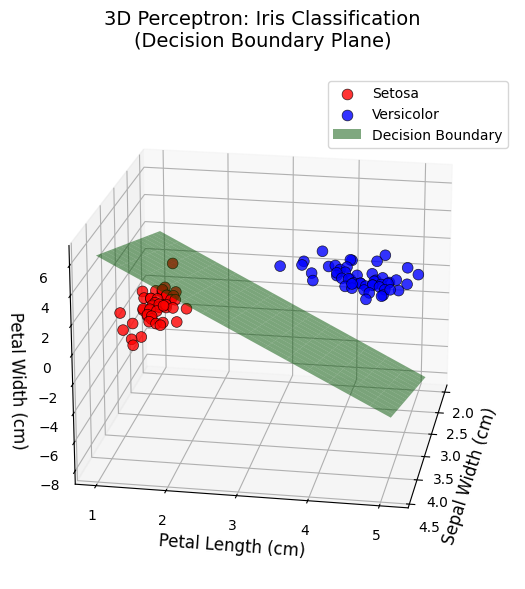

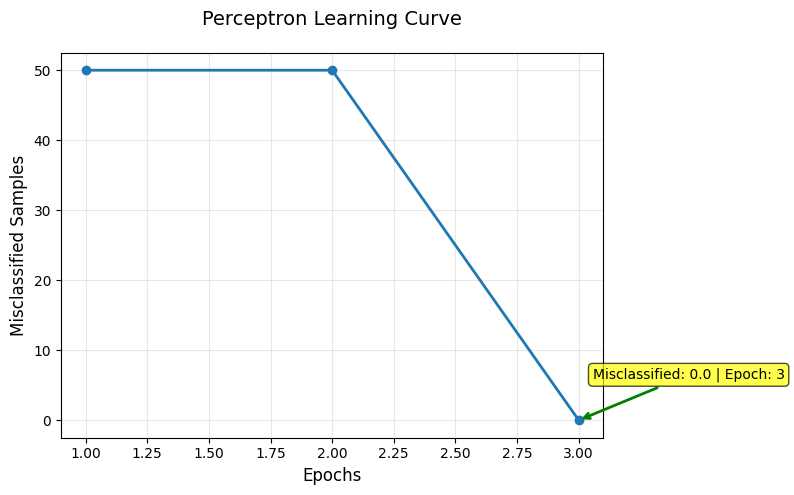

In [78]:
from sklearn.datasets import load_iris

# Load and prepare Iris dataset
iris = load_iris()
X_iris = iris.data  # Shape: (150, 4) - 4 features
y_iris = iris.target  # Shape: (150,) - 3 classes

# Filter dataset: keep only Setosa (0) and Versicolor (1), exclude Virginica (2)
mask = y_iris != 2
X_iris = X_iris[mask]
y_iris = y_iris[mask]

# Select 3 features for 3D visualization
# Features: sepal width (index 1), petal length (index 2), petal width (index 3)
feature_indices = [1, 2, 3]
X_iris = X_iris[:, feature_indices]

# Add bias term (intercept) for linear classification
X_iris = np.column_stack((np.ones(X_iris.shape[0]), X_iris))

# Convert target labels: Setosa (0) -> -1, Versicolor (1) -> 1
y_iris = np.where(y_iris == 0, -1, 1)

# Initialize and train perceptron
perceptron_3d = Perceptron(learning_rate=0.01, epochs=10)
perceptron_3d.fit(X_iris, y_iris)

# Create 3D visualization
# Extract features (excluding bias term)
features = X_iris[:, 1:]
feature_names = ['Sepal Width', 'Petal Length', 'Petal Width']

# Visualization settings
colors = ['red', 'blue']
labels = ['Setosa', 'Versicolor']
class_values = [-1, 1]

# Create 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot data points for each class
for color, label, class_val in zip(colors, labels, class_values):
    mask = (y_iris == class_val)
    ax.scatter(
        features[mask, 0],
        features[mask, 1],
        features[mask, 2],
        c=color,
        s=60,
        label=label,
        alpha=0.8,
        edgecolors='black',
        linewidth=0.5
    )

# Create mesh grid for decision boundary plane
x_min, x_max = features[:, 0].min(), features[:, 0].max()
y_min, y_max = features[:, 1].min(), features[:, 1].max()

# Create grid points
x_range = np.linspace(x_min, x_max, 15)
y_range = np.linspace(y_min, y_max, 15)
xx, yy = np.meshgrid(x_range, y_range)

# Calculate decision boundary plane
# Plane equation: w0 + w1*x + w2*y + w3*z = 0
# Solving for z: z = -(w0 + w1*x + w2*y) / w3
weights = perceptron_3d.weights
zz = -(weights[0] + weights[1] * xx + weights[2] * yy) / weights[3]

# Plot decision boundary plane
ax.plot_surface(
    xx, yy, zz,
    alpha=0.5,
    color='green',
    label='Decision Boundary'
)

# Customize plot appearance
ax.set_xlabel(f'{feature_names[0]} (cm)', fontsize=12)
ax.set_ylabel(f'{feature_names[1]} (cm)', fontsize=12)
ax.set_zlabel(f'{feature_names[2]} (cm)', fontsize=12)
ax.set_title('3D Perceptron: Iris Classification\n(Decision Boundary Plane)',
                fontsize=14, pad=20)

# Set optimal viewing angle
ax.view_init(elev=20, azim=10)

# Add legend and grid
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot learning curve
perceptron_3d.plot_misclassified_history()

## **Logistic Regression**

The **perceptron** gave us our first taste of linear classification: it can draw a straight boundary and decide whether a point lies on one side or the other.  
Elegant in its simplicity, yes — but also painfully limited.

Here’s where the perceptron falls short:

- **Rigid activation**: it uses a harsh step function (sign). No matter if the input score is `-1000` or `-0.001`, the model treats both as the exact same class. Subtle differences in the data vanish instantly.  
- **No sense of confidence**: a point just barely over the line is treated the same as one far away. Imagine a doctor classifying patients as diabetic or not. A patient just above the threshold is labeled diabetic with the same confidence as one far into the danger zone — and tomorrow, with one spoon of sugar less, they might flip back to “healthy.” Clearly, what we need is not just a yes/no verdict, but a *probability* — something like: “There’s a 78% chance this patient is diabetic.”  
- **No gradient for learning**: the step (sign) function has no derivative. In the last chapter, we saw how **gradient descent** thrives on derivatives to adjust parameters smoothly. With the perceptron’s activation, the gradient vanishes — leaving us without the very tool that made optimization possible.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C01/sgn.png" width="600">
</div>

This is exactly where **Logistic Regression** enters the scene. It keeps the linear foundation of the perceptron but replaces the brittle step with the smooth **sigmoid** function. Suddenly, every output becomes a probability between `0` and `1`.  

Logistic Regression is one of the cornerstone algorithms for **binary classification** problems. Despite the name “regression,” its mission is classification. The name comes from its roots in linear regression — but here the outputs are transformed into probabilities, not raw unbounded numbers.

### **Sigmoid Activation Function**

Logistic Regression keeps the **linear model**:

$$
z = w_0 + w_1x_1 + w_2x_2 + \ldots + w_nx_n
$$

However, instead of outputting `z` directly, it passes `z` through the **sigmoid function**, also called the **logistic function**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

This maps any real-valued number `z` into the range `(0, 1)`. The output now represents the **probability** that the input belongs to class 1:

$$
P(y = 1 \mid X) = \sigma(z)
$$

A value close to `1` indicates high confidence for class 1; a value close to `0` indicates high confidence for class 0.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C01/sigmoid.png" width="600">
</div>

The sigmoid function has ideal properties for binary classification:

* It produces smooth probabilities instead of hard jumps.
* It is **differentiable everywhere**, which allows us to compute precise gradients for optimization.
* Its derivative is simple:

  $$
  \sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))
  $$

### **Binary Cross-Entropy Loss**

When working with **regression**, we measured how “wrong” a model’s predictions were using loss functions like **Mean Squared Error (MSE)**. It worked beautifully for continuous outputs, with gradient descent.  

But here’s the problem: **classification outputs are probabilities, not raw numbers**. If we naïvely use MSE on probabilities, several issues arise:  

- **Bad gradients near the extremes**: Suppose the true label is `1` but the model predicts `0.01`. With MSE, the error is only `(1 - 0.01)^2 = 0.98^2 ≈ 0.96`. Big, but not catastrophic. The gradient is also small, meaning the model doesn’t get the strong “kick” it desperately needs to correct itself.  
- **Symmetry where there shouldn’t be**: MSE punishes errors in a “balanced” way, but in classification, misclassifying with high confidence (predicting `0.999` when the truth is `0`) should be punished *far more severely* than a hesitant prediction like `0.55`. MSE doesn’t capture this nuance.  
- **Unnatural geometry**: Regression loss functions assume continuous, unbounded outputs. But classification probabilities live strictly in the interval `[0, 1]`. A loss function for classification must be aligned with probability theory itself.

Because logistic regression outputs **probabilities**, we need a loss that measures how well those probabilities align with the true classes. The natural choice is **Binary Cross-Entropy (Log Loss)**, defined as:

$$
L(y, \hat{y}) = -\Big[\, y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \Big]
$$

Here’s the intuition behind it:

- If the true label is **1**, the loss becomes  
  $
  L = -\log(\hat{y})
  $  
  So the closer $\hat{y}$ is to 1, the smaller the loss. Predicting `0.99` gives a tiny penalty, while predicting `0.01` explodes the loss (since $\log(0.01)$ is a huge negative number).  
- If the true label is **0**, the loss becomes  
  $
  L = -\log(1 - \hat{y})
  $  
  So the closer $\hat{y}$ is to 0, the smaller the loss. Again, being confidently wrong (predicting `0.99` when the truth is `0`) creates a massive penalty.  
- **Key idea**: Cross-entropy is *merciless* against confident mistakes, but forgiving of uncertain ones. If you’re unsure (say, $\hat{y} = 0.6$), the penalty is moderate. If you’re dead certain and wrong, the penalty explodes.  

### **Weight Updates**

Training logistic regression means adjusting the weights to minimize the **binary cross-entropy loss**.  
At first glance, this loss function looks complicated because of the logarithms:

$$
L(y, \hat{y}) = -\big[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \big]
$$

But when we take its derivative with respect to the weights, something beautiful happens: the messy log and sigmoid terms simplify, leaving us with a clean expression.

The gradient of the loss with respect to the weights is going to be:

$$
\nabla J = \frac{\partial L}{\partial w} = X^\mathsf{T}(\hat{y} - y)
$$

- $(\hat{y} - y)$ is the prediction error for each sample.  
- Multiplying by $X^\mathsf{T}$ distributes this error across features according to their contribution.  
- This shows exactly how much each weight should shift to reduce the error.

Finally, we update the weights using **gradient descent**:

$$
w = w - \eta \, \nabla J
$$

where $\eta$ is the learning rate, and $\nabla J$ is the gradient.

Correct Test Predictions Ratio: [103/114] Accuracy: 90.35%


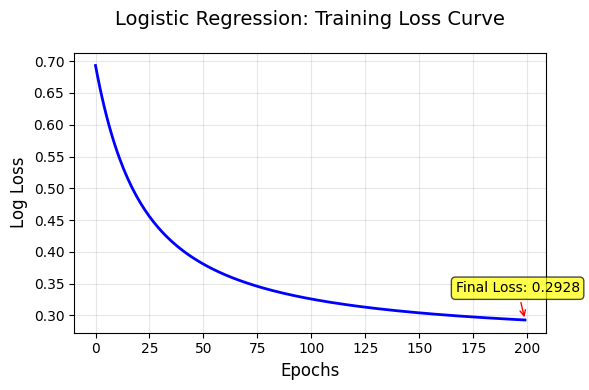

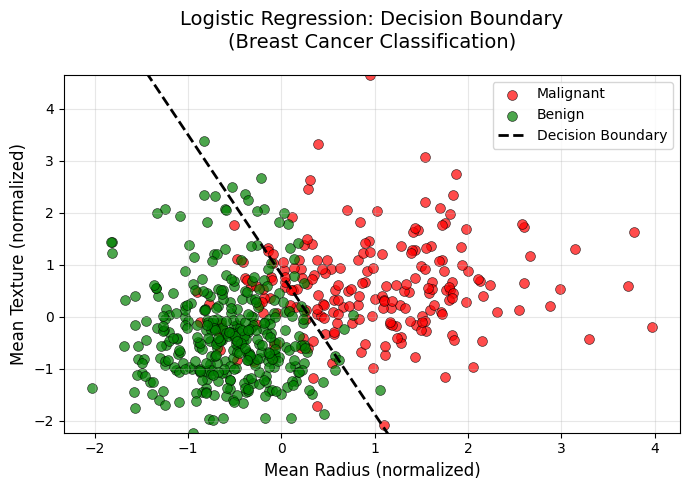

In [80]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

class LogisticRegression:
    """
    Logistic Regression classifier implementation using gradient descent.
    """

    def __init__(self, learning_rate=0.01, epochs=500):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.loss_history = []

    @staticmethod
    def sigmoid(z):
        # Clip z to prevent overflow in exp function
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    @staticmethod
    def log_loss(y_true, y_pred):
        # Add small epsilon to prevent log(0)
        epsilon = 1e-15
        return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

    def fit(self, X, y):
        """
        Train the logistic regression model using gradient descent.
        """
        n_samples, n_features = X.shape

        # Initialize weights to zero
        self.weights = np.zeros(n_features)
        self.loss_history = []

        # Gradient descent optimization
        for epoch in range(self.epochs):
            # Forward pass: compute predictions
            predictions = self.predict_proba(X)

            # Compute error
            error = predictions - y

            # Compute gradients
            gradients = np.dot(X.T, error) / n_samples

            # Update weights
            self.weights -= self.learning_rate * gradients

            # Track loss for this epoch
            current_loss = self.log_loss(y, predictions)
            self.loss_history.append(current_loss)

    def predict_proba(self, X):
        """
        Predict class probabilities.

        Args:
            X (array): Feature matrix

        Returns:
            array: Predicted probabilities for positive class
        """
        linear_combination = np.dot(X, self.weights)
        return self.sigmoid(linear_combination)

    def predict(self, X, threshold=0.5):
        """
        Make binary predictions.

        Args:
            X (array): Feature matrix
            threshold (float): Decision threshold (default: 0.5)

        Returns:
            array: Binary predictions (0 or 1)
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

    def plot_loss_curve(self):
        """Plot the training loss curve."""
        plt.figure(figsize=(6, 4))

        plt.plot(self.loss_history, linewidth=2, color='blue')
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Log Loss', fontsize=12)
        plt.title('Logistic Regression: Training Loss Curve', fontsize=14, pad=20)
        plt.grid(True, alpha=0.3)

        # Annotate final loss
        final_loss = self.loss_history[-1]
        plt.annotate(
            f'Final Loss: {final_loss:.4f}',
            xy=(len(self.loss_history)-1, final_loss),
            xytext=(-50, 20),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='red')
        )

        plt.tight_layout()
        plt.show()

    def plot_decision_boundary(self, X, y, feature_names=None):
        # Extract features (excluding bias term)
        features = X[:, 1:]

        # Default feature names
        if feature_names is None:
            feature_names = ['Feature 1', 'Feature 2']

        # Visualization settings
        colors = ['red', 'green']
        labels = ['Malignant', 'Benign']
        class_values = [0, 1]

        plt.figure(figsize=(7, 5))

        # Plot data points for each class
        for color, label, class_val in zip(colors, labels, class_values):
            mask = (y == class_val)
            plt.scatter(
                features[mask, 0],
                features[mask, 1],
                c=color,
                label=label,
                alpha=0.7,
                s=50,
                edgecolors='black',
                linewidth=0.5
            )

        # Calculate decision boundary line
        # Decision boundary: w0 + w1*x1 + w2*x2 = 0.5 (sigmoid threshold)
        # For logistic regression at threshold 0.5: w0 + w1*x1 + w2*x2 = 0
        # Solving for x2: x2 = -(w0 + w1*x1) / w2
        x1_range = np.linspace(features[:, 0].min(), features[:, 0].max(), 100)
        x2_boundary = -(self.weights[0] + self.weights[1] * x1_range) / self.weights[2]

        # Plot decision boundary
        plt.plot(x1_range, x2_boundary, 'k--', linewidth=2, label='Decision Boundary')

        # Customize plot
        plt.xlabel(feature_names[0], fontsize=12)
        plt.ylabel(feature_names[1], fontsize=12)
        plt.title('Logistic Regression: Decision Boundary\n(Breast Cancer Classification)',
                 fontsize=14, pad=20)
        plt.ylim(features[:, 1].min(), features[:, 1].max())
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Load and prepare breast cancer dataset
cancer_data = load_breast_cancer()
X_cancer = cancer_data.data
y_cancer = cancer_data.target

# Get feature statistics for normalization
feature_means = X_cancer.mean(axis=0)
feature_stds = X_cancer.std(axis=0)

# Normalize features for better convergence
X_cancer_normalized = (X_cancer - feature_means) / feature_stds

# Select first two features for 2D visualization
# Features: mean radius and mean texture
selected_features = X_cancer_normalized[:, :2]

# Add bias term (intercept)
X_cancer_final = np.column_stack((np.ones(selected_features.shape[0]), selected_features))

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cancer_final, y_cancer, test_size=0.2, random_state=42)

# Initialize and train logistic regression model
logistic_model = LogisticRegression(learning_rate=0.1, epochs=200)
logistic_model.fit(X_train, y_train)

# Make predictions on test set
y_test_proba = logistic_model.predict_proba(X_test)
y_test_pred = logistic_model.predict(X_test)

# Calculate and display accuracy
test_accuracy = np.mean(y_test_pred == y_test)
print(f'Correct Test Predictions Ratio: [{np.sum(y_test_pred == y_test)}/{len(y_test)}] Accuracy: {test_accuracy*100:.2f}%')

# Visualize results
logistic_model.plot_loss_curve()
logistic_model.plot_decision_boundary(
    X_cancer_final, y_cancer,
    feature_names=['Mean Radius (normalized)', 'Mean Texture (normalized)']
)

## **Closing This Chapter**

In this chapter, we explored one of the core missions of **supervised learning**: **classification**. Classification is at the heart of countless modern AI applications — from medical diagnostics to spam filters, from image recognition to sentiment analysis — because it turns raw data into clear, discrete decisions.

In this notebook, we covered:

* **The fundamental idea of classification** and how it differs from regression
* The **Perceptron**: our first linear classifier inspired by real neurons
* The move to **Logistic Regression**, which introduced probability, smooth activation with the **sigmoid function**, and a proper differentiable loss — **Binary Cross Entropy (Log Loss)**

All these concepts are cornerstones for deeper models like **Neural Networks** and advanced classifiers that we’ll soon unlock. Mastering these foundations means you understand not just how a prediction happens — but *why* it happens, and how we steer a machine to learn it.

---

### 🚀 **What’s Next?**

In the next chapter, we’ll see a completely different angle on both classification and regression problems:

> **k-Nearest Neighbors (k-NN)**

A model-free **non-parameterized** approach where predictions rely purely on the distances and local structure of the data, not learned weights or equations. It’s a perfect step forward to strengthen your intuition about similarity, local rules, and non-linear boundaries.

Let’s keep going — the real world doesn’t fit into straight lines alone!